# Replacement analysis

Updated as of Sept. 23. This notebook analyzes the cleaned replacements data. 

Subset data through March
- create a subset through March 2025 to match with timeframe of LSI
  
Create a summary file by community area
- this section prepares the data for the replacement rate analysis
- calculate the estimated number of service lines requiring replacement in 2021
- replacement rate is defined as % of service lines requiring replacement in 2021 that have been replaced since 2021
- Exported to csv as total_replacement_rate_by_cca.csv

Correlations
- TK

In [164]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import geopandas as gpd

In [28]:
# load cleaned replacements data
df = pd.read_csv('../processed/replacements_cleaned_updated.csv')
df.head(2)

,Public or Consumer,Work Address,Status,Zip,Ward,Date Completed,program,completed_year,completed_month_year,completed_day,...,geoid,matched_address,m_is_intersection,_merge,geometry,GEOID,NAME,Community Area,CA,completed_day_full
0,PUBLIC,11014 S AVENUE H,Completed,60617,10.0,2025-08-25 15:00:00,Breaks Leaks,2025,08/2025,08-25,...,NaN,NaN,NaN,left_only,POINT (-87.532946029631 41.695162818406),17031520500,5205.0,East Side,52,2025-08-25
1,BOTH AS REQUIRED,1127 W Wolfram,Completed,60657,44.0,2025-08-22 17:09:00,Homeowner Initiated,2025,08/2025,08-22,...,NaN,NaN,NaN,left_only,POINT (-87.657363092128 41.933434330781),17031062900,629.0,Lake View,6,2025-08-22


In [22]:
df.columns

Index(['Public or Consumer', 'Work Address', 'Status', 'Zip', 'Ward',
       'Date Completed', 'program', 'completed_year', 'completed_month_year',
       'completed_day', 'clean_address', 'program_clean_address',
       'full_address', 'row', 'classification_for_entire_service_line',
       'stnum1', 'stnum2', 'stdir', 'stname', 'sttype', 'zip', 'geocoder',
       'lat', 'long', 'geoid', 'matched_address', 'm_is_intersection',
       '_merge', 'geometry', 'GEOID', 'NAME', 'Community Area',
       'completed_day_full'],
      dtype='object')

## Subset data through March

In [29]:
mask = (df['completed_day_full'] < '2025-04-01') 
df_thru_march = df.loc[mask].copy()

In [30]:
print(len(df_thru_march))

10392


## Subset data to see if its on track this year

In [194]:
df[df['completed_year']==2024].groupby('completed_month_year').size().reset_index()

,completed_month_year,0
0,01/2024,214
1,02/2024,284
2,03/2024,345
3,04/2024,479
4,05/2024,305
5,06/2024,325
6,07/2024,368
7,08/2024,454
8,09/2024,479
9,10/2024,548


In [195]:
214+284+345+479+305+325+368+454

2774

In [192]:
print(len(df_thru_2024_ytd))

6990


## Totals by program and year

In [10]:
df.groupby('program').size()

program
Block Level LSLR             230
Breaks Leaks                7927
CIP Sewer and Water Main    1196
Daycare                      343
Equity                      2000
Homeowner Initiated          956
dtype: int64

In [11]:
df_thru_march.groupby('program').size()

program
Block Level LSLR             127
Breaks Leaks                6273
CIP Sewer and Water Main     915
Daycare                      293
Equity                      1915
Homeowner Initiated          869
dtype: int64

In [100]:
g = df.groupby('program').size().reset_index()
g['pct'] = (g[0]/len(df))*100
g

,program,0,pct
0,Block Level LSLR,230,1.817894
1,Breaks Leaks,7927,62.654126
2,CIP Sewer and Water Main,1196,9.453051
3,Daycare,343,2.711034
4,Equity,2000,15.807777
5,Homeowner Initiated,956,7.556118


In [101]:
df.groupby('completed_year').size()

completed_year
2021      28
2022     346
2023    3860
2024    4886
2025    3532
dtype: int64

Look at replacements by month by program to see if targeted ones like equity haven't ramped up as fast.

In [218]:
# replacements by month by program
by_month_by_program = df.groupby(['completed_month_year', 'program'],dropna=False).size().reset_index(name='replacements')

by_month_by_program = by_month_by_program.fillna(0)
by_month_by_program['completed_month_year'] = pd.to_datetime(by_month_by_program['completed_month_year'])
by_month_by_program = by_month_by_program.sort_values('completed_month_year')
by_month_by_program.tail()

/var/folders/4l/t591xjt528jfczvfrdl8nnz40000gr/T/ipykernel_17016/494028890.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  by_month_by_program['completed_month_year'] = pd.to_datetime(by_month_by_program['completed_month_year'])


,completed_month_year,program,replacements
146,2025-08-01,Homeowner Initiated,5
141,2025-08-01,Block Level LSLR,29
142,2025-08-01,Breaks Leaks,136
145,2025-08-01,Equity,32
189,2025-11-01,Breaks Leaks,1


In [219]:
# check
by_month_by_program['replacements'].sum()

np.int64(12652)

In [274]:
# export
by_month_by_program.to_csv('../processed/replacements_by_month_by_program_thru_aug.csv',index=False)

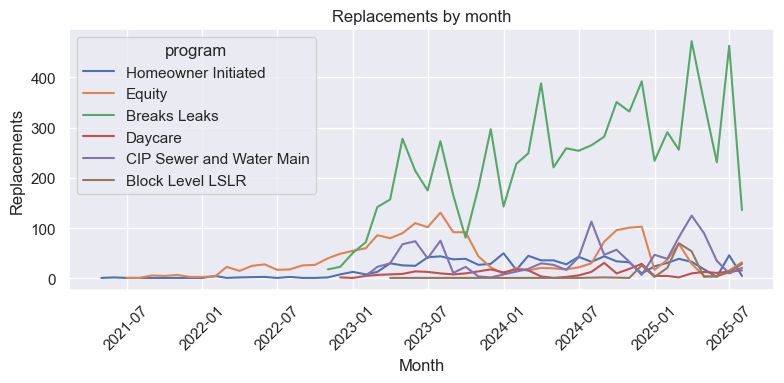

In [208]:
# plot on multi-line charts

by_month_by_program.drop(by_month_by_program.tail(1).index,inplace=True) # drop nov date for viz

sns.set(style='darkgrid')

plt.figure(figsize=(8, 4))
sns.lineplot(data=by_month_by_program, x='completed_month_year', y='replacements', hue='program')

plt.xlabel('Month')
plt.ylabel('Replacements')
plt.title('Replacements by month')
plt.xticks(rotation=45)
plt.tight_layout()

And then by year and YTD for a finding for the story?

In [215]:
df['completed_year'] = df['completed_year'].astype(str)

In [216]:
# replacements by year by program
by_year_by_program = df.groupby(['completed_year', 'program']).size().reset_index(name='replacements')

by_year_by_program = by_year_by_program.fillna(0)
by_year_by_program = by_year_by_program.sort_values('completed_year')
by_year_by_program.tail()

,completed_year,program,replacements
18,2025,Block Level LSLR,197
19,2025,Breaks Leaks,2435
20,2025,CIP Sewer and Water Main,449
21,2025,Daycare,62
23,2025,Homeowner Initiated,181


In [217]:
by_year_by_program

,completed_year,program,replacements
0,2021,Equity,23
1,2021,Homeowner Initiated,5
2,2022,Breaks Leaks,41
3,2022,Daycare,2
4,2022,Equity,275
5,2022,Homeowner Initiated,28
10,2023,Equity,964
9,2023,Daycare,117
11,2023,Homeowner Initiated,334
7,2023,Breaks Leaks,2087


## Create a summary file by community area

Find the denominator for the rate, the estimated total number of suspected lead service lines in 2021 by community area by adding the number of suspected lines as of March and the number replaced as of March.

In [196]:
# group by cca thru march
total_by_cca_program_thru_march = pd.pivot_table(df_thru_march,
              index='Community Area',
              columns='program',
              values='program_clean_address',
              aggfunc='count',
              dropna=False).reset_index()

total_by_cca_program_thru_march = total_by_cca_program_thru_march.fillna(0)
total_by_cca_program_thru_march['Community Area'] = total_by_cca_program_thru_march['Community Area'].str.upper()

# add total replaced
col_list = ['Block Level LSLR', 'Breaks Leaks', 'CIP Sewer and Water Main','Daycare', 'Equity', 'Homeowner Initiated']
total_by_cca_program_thru_march['total_replacements_thru_march'] = total_by_cca_program_thru_march[col_list].sum(axis=1)

total_by_cca_program_thru_march

program,Community Area,Block Level LSLR,Breaks Leaks,CIP Sewer and Water Main,Daycare,Equity,Homeowner Initiated,total_replacements_thru_march
0,ALBANY PARK,0.0,113.0,45.0,0.0,15.0,22.0,195.0
1,ARCHER HEIGHTS,0.0,42.0,0.0,1.0,19.0,0.0,62.0
2,ARMOUR SQUARE,0.0,15.0,0.0,0.0,3.0,3.0,21.0
3,ASHBURN,0.0,136.0,1.0,6.0,60.0,0.0,203.0
4,AUBURN GRESHAM,0.0,170.0,129.0,7.0,70.0,5.0,381.0
...,...,...,...,...,...,...,...,...
70,WEST LAWN,0.0,95.0,0.0,1.0,27.0,0.0,123.0
71,WEST PULLMAN,0.0,88.0,0.0,23.0,94.0,2.0,207.0
72,WEST RIDGE,0.0,93.0,0.0,4.0,40.0,17.0,154.0
73,WEST TOWN,0.0,133.0,27.0,0.0,7.0,85.0,252.0


In [197]:
# read in inventory data by cca
inv_cca = pd.read_csv('../peter-aldhous/chicago_community_areas (1).csv')
inv_cca.head()

,community,area_num_1,GRR,L,NL,U,total,flag,lead_plus_suspected,requires_replacement,...,Y,NA,pct_replaced,median_household_income,pct_poverty,pct_hispanic,pct_white_nonhispanic,pct_black_nonhispanic,pct_asian_nonhispanic,pct_minority
0,Rogers Park,1,129,746,836,2118,3829,False,2864,2993,...,54,0,1.4,59552.907508,18.1,21.1,44.6,23.3,5.8,55.4
1,West Ridge,2,137,2920,1031,5931,10019,False,8851,8988,...,119,1,1.2,71524.002706,17.4,21.9,38.7,11.7,21.8,61.3
2,Uptown,3,37,465,1370,1509,3381,False,1974,2011,...,43,0,1.3,68443.897980,20.7,14.0,50.9,20.0,10.4,49.1
3,Lincoln Square,4,119,1864,1438,2703,6124,False,4567,4686,...,110,0,1.8,93604.920261,9.6,19.8,60.9,4.4,9.2,39.1
4,North Center,5,126,1611,3125,2491,7353,False,4102,4228,...,84,0,1.1,145156.056471,4.7,13.3,73.1,2.2,6.2,26.9


In [198]:
inv_cca.columns

Index(['community', 'area_num_1', 'GRR', 'L', 'NL', 'U', 'total', 'flag',
       'lead_plus_suspected', 'requires_replacement', 'pct_lead', 'pct_grr',
       'pct_suspected_lead', 'pct_lead_plus_suspected',
       'pct_requires_replacement', 'pct_not_lead', 'N', 'Y', 'NA',
       'pct_replaced', 'median_household_income', 'pct_poverty',
       'pct_hispanic', 'pct_white_nonhispanic', 'pct_black_nonhispanic',
       'pct_asian_nonhispanic', 'pct_minority'],
      dtype='object')

In [199]:
# merge
cca_analysis = pd.merge(total_by_cca_program_thru_march[['Community Area', 'total_replacements_thru_march']], inv_cca[['community', 'requires_replacement', 'pct_requires_replacement', 'total','Y', 'N', 'pct_replaced', 'pct_poverty',
                                                                 'pct_hispanic', 'pct_white_nonhispanic', 'pct_black_nonhispanic', 'pct_asian_nonhispanic',
                                                                 'pct_minority', 'median_household_income']],
                       left_on='Community Area', right_on=inv_cca['community'].str.upper(), how='right')

In [65]:
cca_analysis['total_suspected_2021'] = cca_analysis['requires_replacement'] + cca_analysis['total_replacements_thru_march']

In [66]:
cca_analysis.head()

,Community Area,total_replacements_thru_march,community,requires_replacement,pct_requires_replacement,total,Y,N,pct_replaced,pct_poverty,pct_hispanic,pct_white_nonhispanic,pct_black_nonhispanic,pct_asian_nonhispanic,pct_minority,median_household_income,total_suspected_2021
0,ROGERS PARK,79.0,Rogers Park,2993,78.2,3829,54,3775,1.4,18.1,21.1,44.6,23.3,5.8,55.4,59552.907508,3072.0
1,WEST RIDGE,154.0,West Ridge,8988,89.7,10019,119,9899,1.2,17.4,21.9,38.7,11.7,21.8,61.3,71524.002706,9142.0
2,UPTOWN,54.0,Uptown,2011,59.5,3381,43,3338,1.3,20.7,14.0,50.9,20.0,10.4,49.1,68443.897980,2065.0
3,LINCOLN SQUARE,123.0,Lincoln Square,4686,76.5,6124,110,6014,1.8,9.6,19.8,60.9,4.4,9.2,39.1,93604.920261,4809.0
4,NORTH CENTER,95.0,North Center,4228,57.5,7353,84,7269,1.1,4.7,13.3,73.1,2.2,6.2,26.9,145156.056471,4323.0


Merge denominator info with replacements as of August

In [67]:
# group by cca thru aug
total_by_cca_program_thru_aug = pd.pivot_table(df,
              index='Community Area',
              columns='program',
              values='program_clean_address',
              aggfunc='count',
              dropna=False).reset_index()

total_by_cca_program_thru_aug = total_by_cca_program_thru_aug.fillna(0)
total_by_cca_program_thru_aug['Community Area'] = total_by_cca_program_thru_aug['Community Area'].str.upper()

# add total replaced
col_list = ['Block Level LSLR', 'Breaks Leaks', 'CIP Sewer and Water Main','Daycare', 'Equity', 'Homeowner Initiated']
total_by_cca_program_thru_aug['total_replacements_thru_aug'] = total_by_cca_program_thru_aug[col_list].sum(axis=1)

total_by_cca_program_thru_aug.tail(2)

program,Community Area,Block Level LSLR,Breaks Leaks,CIP Sewer and Water Main,Daycare,Equity,Homeowner Initiated,total_replacements_thru_aug
73,WEST TOWN,0.0,167.0,116.0,0.0,7.0,94.0,384.0
74,WOODLAWN,11.0,55.0,11.0,6.0,14.0,9.0,106.0


In [68]:
total_by_cca_program_thru_aug['total_replacements_thru_aug'].sum()

np.float64(12652.0)

In [69]:
# merge
cca_analysis = pd.merge(cca_analysis, total_by_cca_program_thru_aug, on='Community Area', how='left')

In [70]:
cca_analysis['total_replacements_thru_aug'].sum()

np.float64(12652.0)

In [71]:
# calc rate
cca_analysis['pct_replaced_aug'] = cca_analysis['total_replacements_thru_aug']/cca_analysis['total_suspected_2021']

In [73]:
# calc pct requiring replacement in 2021
cca_analysis['pct_requiring_replacement_2021'] = cca_analysis['total_suspected_2021']/cca_analysis['total']

In [91]:
# categorize cca's with majority race
def majority_race(row):
    if row['pct_white_nonhispanic'] > 50:
        return 'white'
    elif row['pct_black_nonhispanic'] > 50:
        return 'black'
    elif row['pct_hispanic'] > 50:
        return 'latino'
    elif row['pct_asian_nonhispanic'] > 50:
        return 'asian'
    else:
        return 'no majority'

cca_analysis['majority_race'] = cca_analysis.apply(majority_race, axis=1)

In [92]:
cca_analysis.groupby('majority_race').size()

majority_race
asian           1
black          28
latino         19
no majority    10
white          19
dtype: int64

## Export as csv!

In [93]:
cca_analysis.to_csv('../processed/total_replacement_rate_by_cca_thru_aug.csv', index=False)

## Analysis by community area

Little correlation between communities/tracts that have rate of replacements and communities/tracts with the highest share of lines that require replacement.

<Axes: xlabel='pct_requiring_replacement_2021', ylabel='pct_replaced_aug'>

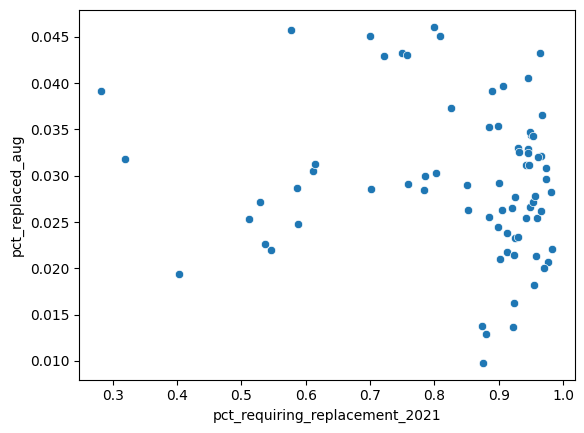

In [74]:
sns.scatterplot(data=cca_analysis, x='pct_requiring_replacement_2021', y='pct_replaced_aug')

In [80]:
print(cca_analysis['pct_requiring_replacement_2021'].corr(cca_analysis['pct_replaced_aug']))

-0.13665142866177657


It's actually negatively linearly correlated

<Axes: xlabel='pct_requires_replacement', ylabel='pct_replaced_aug'>

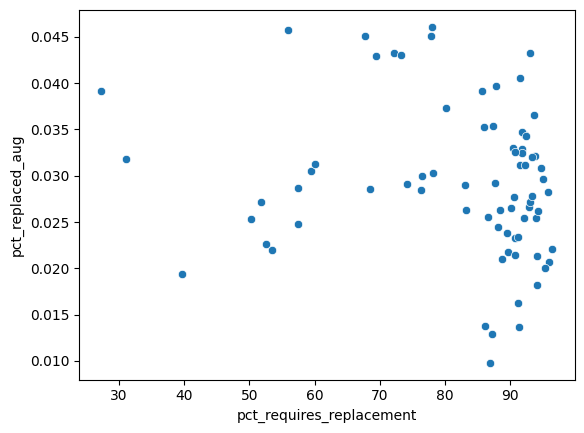

In [75]:
sns.scatterplot(data=cca_analysis, x='pct_requires_replacement', y='pct_replaced_aug')

In [81]:
print(cca_analysis['pct_requires_replacement'].corr(cca_analysis['pct_replaced_aug']))

-0.1680386761081955


Majority black communities have the highest replacement rate, over the citywide rate, but majority latino communities are lagging behind majority white.

In [96]:
g = cca_analysis.groupby('majority_race')[['total_replacements_thru_aug', 'total_suspected_2021','total']].sum()
g['pct_replaced'] = g['total_replacements_thru_aug']/g['total_suspected_2021']
g['pct_requires_replacement_2021'] = g['total_suspected_2021']/g['total']
g

,total_replacements_thru_aug,total_suspected_2021,total,pct_replaced,pct_requires_replacement_2021
majority_race,,,,,
asian,23.0,1045.0,1915,0.022010,0.545692
black,4758.0,140434.0,152964,0.033881,0.918085
latino,3268.0,119682.0,129217,0.027306,0.926209
no majority,1855.0,64793.0,76675,0.028630,0.845034
white,2748.0,96113.0,130174,0.028591,0.738343


## Maps by community area

In [180]:
# load cca chicago
cca = gpd.read_file('../../common-geographies/chicago_community_areas.geojson')

In [181]:
cca.head(2)

,community,shape_area,area_num_1,area_numbe,shape_len,geometry
0,ROGERS PARK,51259902.4506,1,1,34052.3975757,"MULTIPOLYGON (((-87.65456 41.99817, -87.65574 ..."
1,WEST RIDGE,98429094.8621,2,2,43020.6894583,"MULTIPOLYGON (((-87.68465 42.01948, -87.68464 ..."


In [183]:
# merge with tract analysis
cca_map = pd.merge(cca, cca_analysis, left_on='community', right_on='Community Area', how='left')
print(len(cca_map))

77


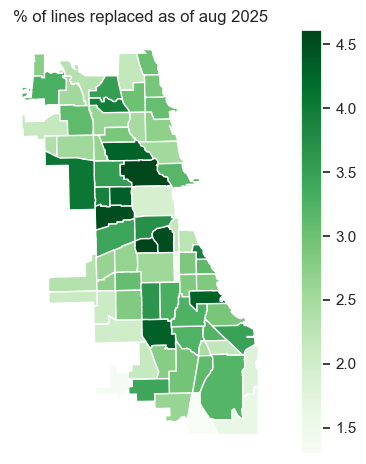

In [221]:
fig, ax = plt.subplots()

cca_map.plot(ax=ax, column=cca_map['pct_replaced_aug'] * 100, cmap='Greens', legend=True)
ax.set_title('% of lines replaced as of aug 2025')
ax.axis('off')
plt.tight_layout() # adjust layout
plt.show()

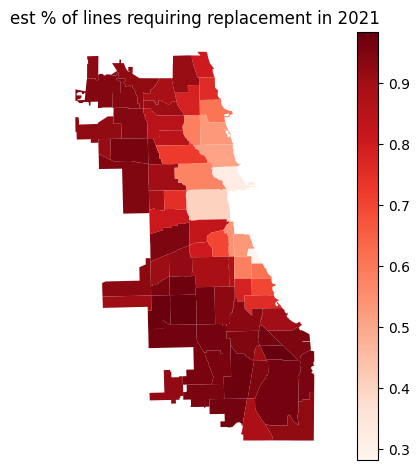

In [185]:
fig, ax = plt.subplots()

cca_map.plot(ax=ax, column='pct_requiring_replacement_2021', cmap='Reds', legend=True)
ax.set_title('est % of lines requiring replacement in 2021')
ax.axis('off')
plt.tight_layout() # adjust layout
plt.show()

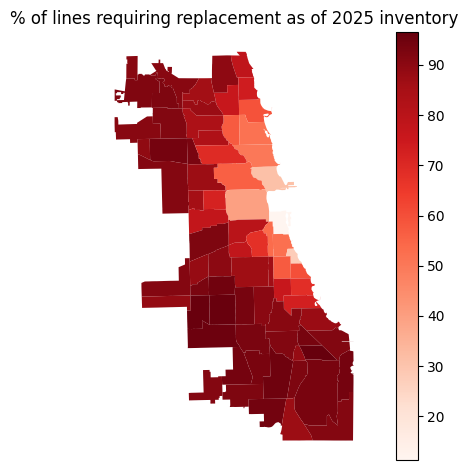

In [188]:
fig, ax = plt.subplots()

cca_map.plot(ax=ax, column='pct_requires_replacement', cmap='Reds', legend=True)
ax.set_title('% of lines requiring replacement as of 2025 inventory')
ax.axis('off')
plt.tight_layout() # adjust layout
plt.show()

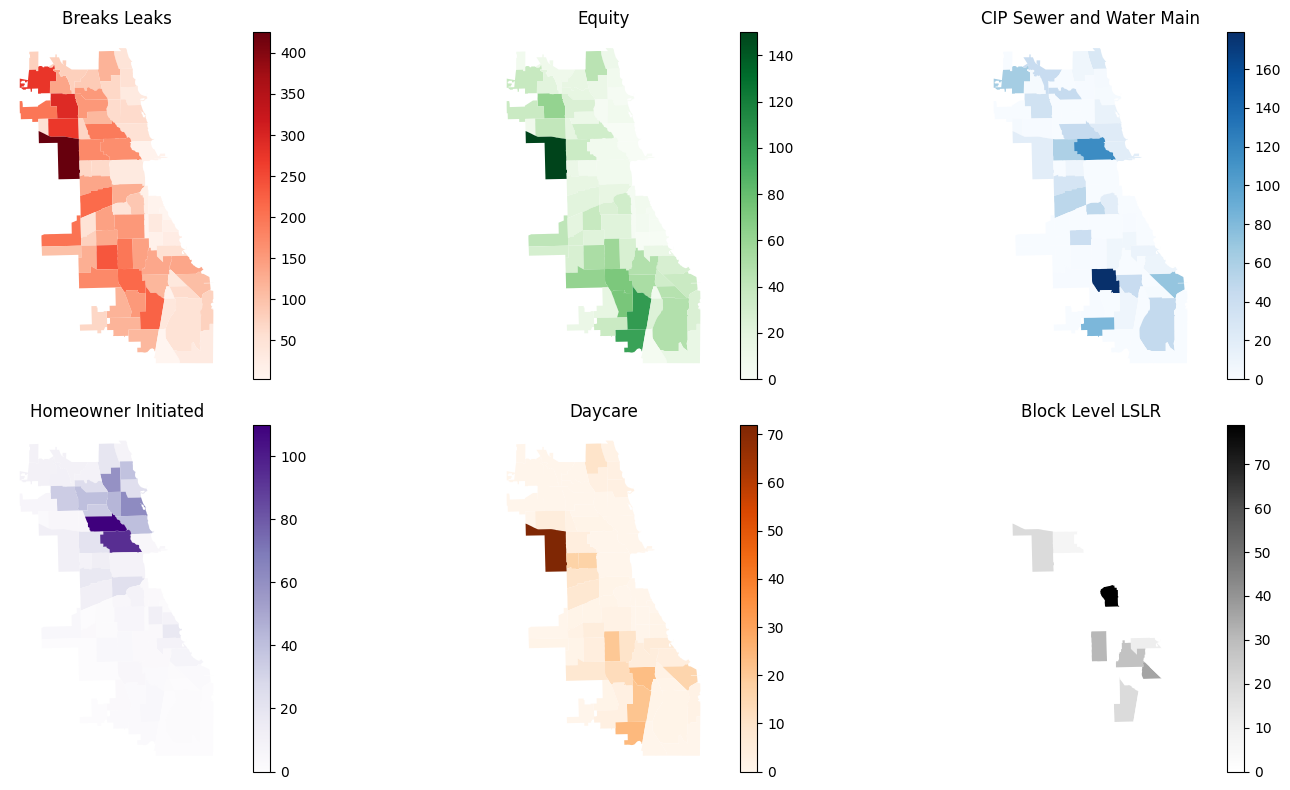

In [189]:
# Create a figure with 6 subplots (2 rows, 3 columns)
fig, ax = plt.subplots(2, 3, figsize=(16, 8))

# Flatten axes for easy indexing
ax = ax.flatten()

# Plot on the first subplot
cca_map.plot(ax=ax[0], column='Breaks Leaks', cmap='Reds', legend=True)
ax[0].set_title('Breaks Leaks')

# Plot on the second subplot
cca_map.plot(ax=ax[1], column='Equity', cmap='Greens', legend=True)
ax[1].set_title('Equity')

# Plot on the third subplot
cca_map.plot(ax=ax[2], column='CIP Sewer and Water Main', cmap='Blues', legend=True)
ax[2].set_title('CIP Sewer and Water Main')

# Plot on the fourth subplot
cca_map.plot(ax=ax[3], column='Homeowner Initiated', cmap='Purples', legend=True)
ax[3].set_title('Homeowner Initiated')

cca_map.plot(ax=ax[4], column='Daycare', cmap='Oranges', legend=True)
ax[4].set_title('Daycare')

cca_map.plot(ax=ax[5], column='Block Level LSLR', cmap='Greys', legend=True)
ax[5].set_title('Block Level LSLR')

ax[0].axis('off')
ax[1].axis('off')
ax[2].axis('off')
ax[3].axis('off')
ax[4].axis('off')
ax[5].axis('off')

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

## Create a summary file by tract

In [136]:
# group by tract thru march
total_by_tract_program_thru_march = pd.pivot_table(df_thru_march,
              index='GEOID',
              columns='program',
              values='program_clean_address',
              aggfunc='count',
              dropna=False).reset_index()

total_by_tract_program_thru_march = total_by_tract_program_thru_march.fillna(0)

# add total replaced
col_list = ['Block Level LSLR', 'Breaks Leaks', 'CIP Sewer and Water Main','Daycare', 'Equity', 'Homeowner Initiated']
total_by_tract_program_thru_march['total_replacements_thru_march'] = total_by_tract_program_thru_march[col_list].sum(axis=1)

total_by_tract_program_thru_march

program,GEOID,Block Level LSLR,Breaks Leaks,CIP Sewer and Water Main,Daycare,Equity,Homeowner Initiated,total_replacements_thru_march
0,17031010100,0.0,3.0,5.0,0.0,1.0,0.0,9.0
1,17031010201,0.0,2.0,0.0,0.0,2.0,0.0,4.0
2,17031010202,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3,17031010300,0.0,5.0,22.0,0.0,0.0,2.0,29.0
4,17031010400,0.0,2.0,0.0,0.0,0.0,0.0,2.0
...,...,...,...,...,...,...,...,...
728,17031843700,0.0,1.0,0.0,0.0,0.0,6.0,7.0
729,17031843800,0.0,13.0,0.0,0.0,1.0,0.0,14.0
730,17031843900,0.0,2.0,0.0,0.0,0.0,0.0,2.0
731,17031844600,0.0,0.0,0.0,0.0,0.0,1.0,1.0


In [137]:
# check, should be 10392
total_by_tract_program_thru_march['total_replacements_thru_march'].sum()

np.float64(10392.0)

In [138]:
# read in inventory data by tract
inv_tracts = pd.read_csv('../peter-aldhous/chicago_tracts.csv')
inv_tracts.head()

,geoid,pct_poverty,median_household_income,pct_hispanic,pct_black_nonhispanic,pct_white_nonhispanic,pct_asian_nonhispanic,pct_minority,households,pct_limited_or_no_english,...,requires_replacement,pct_lead,pct_grr,pct_suspected_lead,pct_lead_plus_suspected,pct_requires_replacement,pct_not_lead,N,Y,pct_replaced
0,17031030101,17.5,49132.0,9.1,20.2,47.1,17.8,52.9,2162,6.4,...,33.0,8.1,0.0,45.2,53.2,53.2,46.8,62.0,0.0,0.0
1,17031030701,19.7,51625.0,12.9,33.2,45.7,5.6,54.3,894,1.9,...,17.0,7.0,0.0,32.6,39.5,39.5,60.5,42.0,1.0,2.3
2,17031070103,13.4,76477.0,6.3,8.7,69.2,6.1,30.8,1133,0.0,...,60.0,32.2,0.0,36.8,69.0,69.0,31.0,84.0,3.0,3.4
3,17031770602,3.8,85913.0,54.8,1.0,32.7,8.7,67.3,1541,18.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,17031841200,14.0,62819.0,83.0,2.5,13.6,0.0,86.4,1796,13.3,...,631.0,9.8,1.1,73.7,83.5,84.6,15.4,734.0,12.0,1.6


In [139]:
# merge
tract_analysis = pd.merge(total_by_tract_program_thru_march[['GEOID', 'total_replacements_thru_march']], inv_tracts[['geoid', 'requires_replacement', 'pct_requires_replacement', 'total','Y', 'N', 'pct_replaced', 'pct_poverty',
                                                                 'pct_hispanic', 'pct_white_nonhispanic', 'pct_black_nonhispanic', 'pct_asian_nonhispanic',
                                                                 'pct_minority', 'median_household_income']],
                       left_on='GEOID', right_on='geoid', how='right', indicator=True)

In [140]:
# check, should be 10392
tract_analysis['total_replacements_thru_march'].sum()

np.float64(10392.0)

In [142]:
# should be 491,384
tract_analysis['total'].sum()

np.float64(491384.0)

In [141]:
tract_analysis.head(2)

,GEOID,total_replacements_thru_march,geoid,requires_replacement,pct_requires_replacement,total,Y,N,pct_replaced,pct_poverty,pct_hispanic,pct_white_nonhispanic,pct_black_nonhispanic,pct_asian_nonhispanic,pct_minority,median_household_income,_merge
0,NaN,NaN,17031030101,33.0,53.2,62.0,0.0,62.0,0.0,17.5,9.1,47.1,20.2,17.8,52.9,49132.0,right_only
1,1.703103e+10,1.0,17031030701,17.0,39.5,43.0,1.0,42.0,2.3,19.7,12.9,45.7,33.2,5.6,54.3,51625.0,both


In [143]:
tract_analysis['total_suspected_2021'] = tract_analysis['requires_replacement'] + tract_analysis['total_replacements_thru_march']

In [144]:
tract_analysis.tail(2)

,GEOID,total_replacements_thru_march,geoid,requires_replacement,pct_requires_replacement,total,Y,N,pct_replaced,pct_poverty,pct_hispanic,pct_white_nonhispanic,pct_black_nonhispanic,pct_asian_nonhispanic,pct_minority,median_household_income,_merge,total_suspected_2021
797,1.703155e+10,22.0,17031550100,1777.0,88.8,2002.0,21.0,1981.0,1.0,12.6,48.6,31.3,18.3,1.3,68.7,52174.0,both,1799.0
798,1.703171e+10,10.0,17031710300,251.0,91.9,273.0,6.0,267.0,2.2,17.0,3.5,0.0,95.6,0.9,100.0,54886.0,both,261.0


In [145]:
# merge denominator with replacements as of aug

# group by tract thru aug
total_by_tract_program_thru_aug = pd.pivot_table(df,
              index='GEOID',
              columns='program',
              values='program_clean_address',
              aggfunc='count',
              dropna=False).reset_index()

total_by_tract_program_thru_aug = total_by_tract_program_thru_aug.fillna(0)

# add total replaced
col_list = ['Block Level LSLR', 'Breaks Leaks', 'CIP Sewer and Water Main','Daycare', 'Equity', 'Homeowner Initiated']
total_by_tract_program_thru_aug['total_replacements_thru_aug'] = total_by_tract_program_thru_aug[col_list].sum(axis=1)

total_by_tract_program_thru_aug.tail(2)

program,GEOID,Block Level LSLR,Breaks Leaks,CIP Sewer and Water Main,Daycare,Equity,Homeowner Initiated,total_replacements_thru_aug
738,17031844600,0.0,1.0,0.0,0.0,0.0,2.0,3.0
739,17031844700,0.0,19.0,29.0,0.0,4.0,1.0,53.0


In [146]:
# check, should equal 12,652
total_by_tract_program_thru_aug['total_replacements_thru_aug'].sum()

np.float64(12652.0)

In [147]:
# merge
tract_analysis = pd.merge(tract_analysis, total_by_tract_program_thru_aug, on='GEOID', how='outer')

In [148]:
tract_analysis['total_replacements_thru_aug'].sum()

np.float64(12652.0)

In [149]:
tract_analysis['total'].sum()

np.float64(491384.0)

In [150]:
# calc rate
tract_analysis['pct_replaced_aug'] = tract_analysis['total_replacements_thru_aug']/tract_analysis['total_suspected_2021']

In [151]:
# calc pct requiring replacement in 2021
tract_analysis['pct_requiring_replacement_2021'] = tract_analysis['total_suspected_2021']/tract_analysis['total']

In [152]:
# categorize cca's with majority race
tract_analysis['majority_race'] = tract_analysis.apply(majority_race, axis=1)

In [153]:
tract_analysis.groupby('majority_race').size()

majority_race
asian            9
black          263
latino         168
no majority    131
white          235
dtype: int64

## Export as csv!

In [154]:
tract_analysis.to_csv('../processed/total_replacement_rate_by_tract_thru_aug.csv', index=False)

In [155]:
inv_tracts['total'].sum()

np.float64(491384.0)

In [156]:
tract_analysis['total'].sum()

np.float64(491384.0)

### Create a summary file by tract just for counts

In [235]:
tracts_by_count = pd.pivot_table(df,
              index='GEOID',
              columns='program',
              values='program_clean_address',
              aggfunc='count',
              dropna=False).reset_index()

tracts_by_count = tracts_by_count.fillna(0)

In [240]:
tracts_by_count.to_csv('../processed/replacement_count_by_tract.csv', index=False)

## Analysis by tract

<Axes: xlabel='pct_requiring_replacement_2021', ylabel='pct_replaced_aug'>

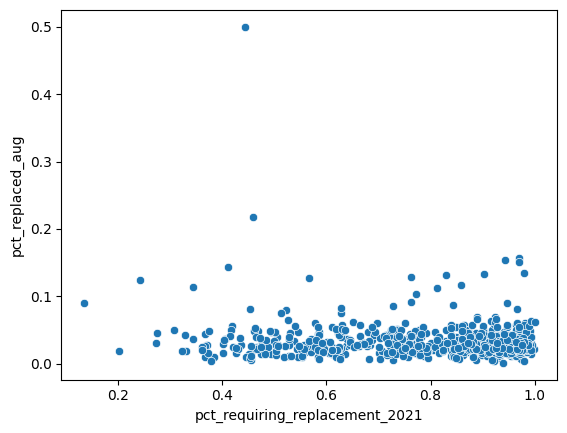

In [157]:
sns.scatterplot(data=tract_analysis, x='pct_requiring_replacement_2021', y='pct_replaced_aug')

<Axes: xlabel='pct_requiring_replacement_2021', ylabel='pct_replaced_aug'>

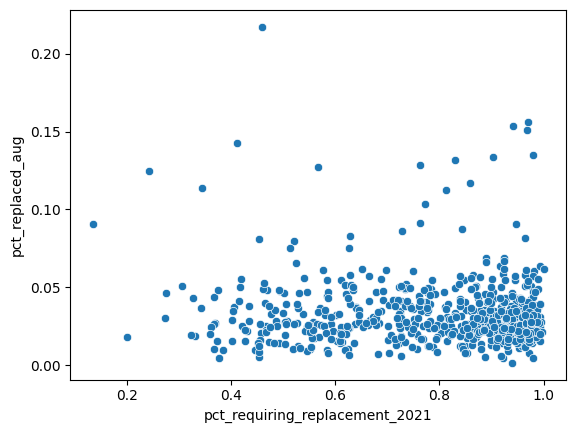

In [158]:
# remove outlier tract with 2/4 suspected replaced
sns.scatterplot(data=tract_analysis[tract_analysis['GEOID'] != 17031063303], x='pct_requiring_replacement_2021', y='pct_replaced_aug')

In [159]:
print(tract_analysis['pct_requiring_replacement_2021'].corr(tract_analysis['pct_replaced_aug']))

-0.1226387689701098


<Axes: xlabel='pct_minority', ylabel='pct_replaced_aug'>

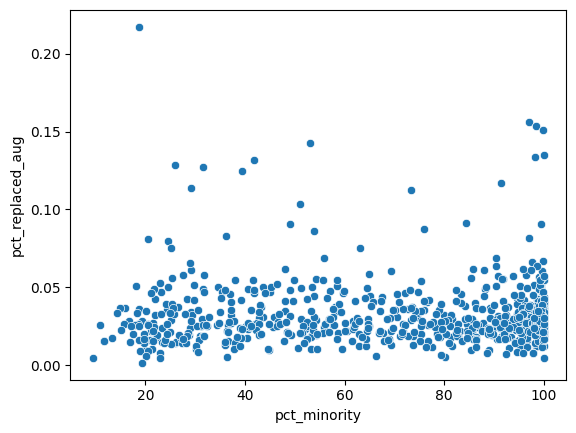

In [161]:
sns.scatterplot(data=tract_analysis[tract_analysis['GEOID'] != 17031063303], x='pct_minority', y='pct_replaced_aug')

In [162]:
print(tract_analysis['pct_minority'].corr(tract_analysis['pct_replaced_aug']))

-0.04206360404977738


Slight negative correlation with income, meaning lower income tracts have a higher replacement rate.

<Axes: xlabel='median_household_income', ylabel='pct_replaced_aug'>

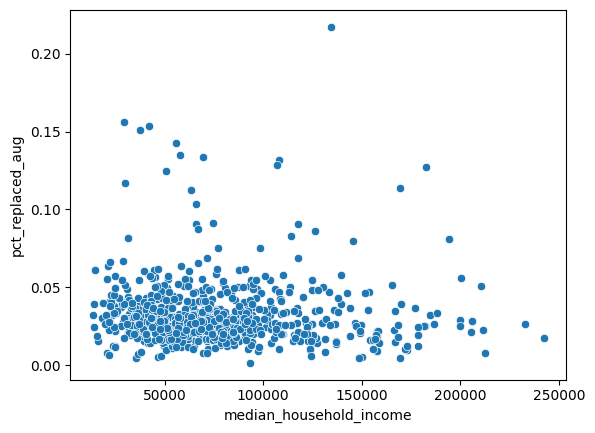

In [170]:
sns.scatterplot(data=tract_analysis[tract_analysis['GEOID'] != 17031063303], x='median_household_income', y='pct_replaced_aug')

In [171]:
print(tract_analysis['median_household_income'].corr(tract_analysis['pct_replaced_aug']))

-0.01461428985524111


In [179]:
g = tract_analysis.groupby('majority_race')[['total_replacements_thru_aug', 'total_suspected_2021','total']].sum()
g['pct_replaced'] = g['total_replacements_thru_aug']/g['total_suspected_2021']
g['pct_requires_replacement_2021'] = g['total_suspected_2021']/g['total']
g

,total_replacements_thru_aug,total_suspected_2021,total,pct_replaced,pct_requires_replacement_2021
majority_race,,,,,
asian,160.0,3176.0,4705.0,0.050378,0.675027
black,4821.0,144596.0,158878.0,0.033341,0.910107
latino,3101.0,116089.0,124029.0,0.026712,0.935983
no majority,1766.0,58127.0,71489.0,0.030382,0.813090
white,2804.0,98264.0,132283.0,0.028535,0.742832


## Maps by tract

In [165]:
# load 2020 tracts for chicago
tracts = gpd.read_file('../../common-geographies/chicago_tracts.geojson')

In [166]:
tracts['GEOID'] = tracts['GEOID'].astype(int)

In [230]:
len(tracts)

792

In [168]:
# merge with tract analysis
tract_map = pd.merge(tracts, tract_analysis, left_on='GEOID', right_on='GEOID', how='left')

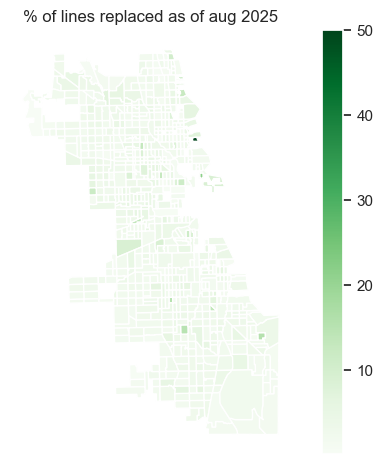

In [222]:
fig, ax = plt.subplots()

tract_map.plot(ax=ax, column=tract_map['pct_replaced_aug']*100, cmap='Greens', legend=True)
ax.set_title('% of lines replaced as of aug 2025')
ax.axis('off')
plt.tight_layout() # adjust layout
plt.show()

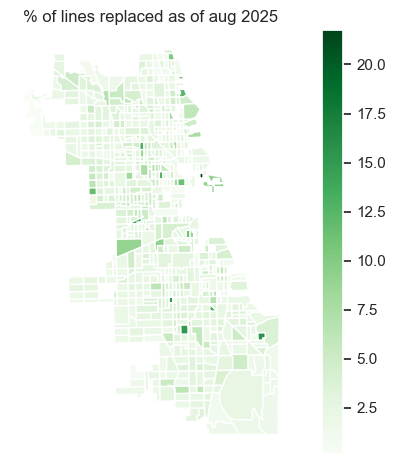

In [224]:
# remove outlier 
# https://censusreporter.org/profiles/14000US17031063303-census-tract-63303-cook-il/
fig, ax = plt.subplots()

tract_map_no_outlier = tract_map[tract_map['GEOID'] != 17031063303].copy()

tract_map_no_outlier.plot(ax=ax, column=tract_map_no_outlier['pct_replaced_aug']*100, cmap='Greens', legend=True)
ax.set_title('% of lines replaced as of aug 2025')
ax.axis('off')
plt.tight_layout() # adjust layout
plt.show()

In [225]:
# map histogram of pct replaced by census tract
tract_analysis['pct_replaced_aug'].describe()

count    733.000000
mean       0.032964
std        0.027073
min        0.001479
25%        0.020888
50%        0.027505
75%        0.037587
max        0.500000
Name: pct_replaced_aug, dtype: float64

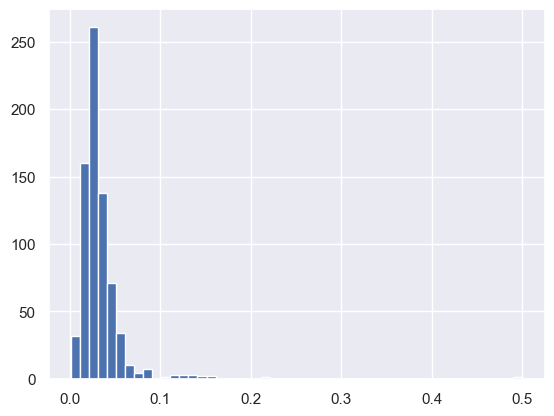

In [229]:
n_bins = 50

tract_analysis['pct_replaced_aug'].hist(bins=n_bins)

plt.show()

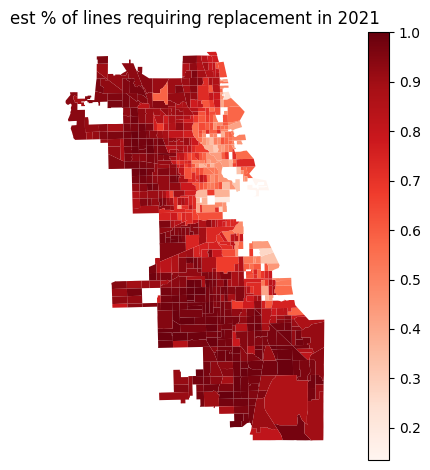

In [174]:
fig, ax = plt.subplots()

tract_map.plot(ax=ax, column='pct_requiring_replacement_2021', cmap='Reds', legend=True)
ax.set_title('est % of lines requiring replacement in 2021')
ax.axis('off')
plt.tight_layout() # adjust layout
plt.show()

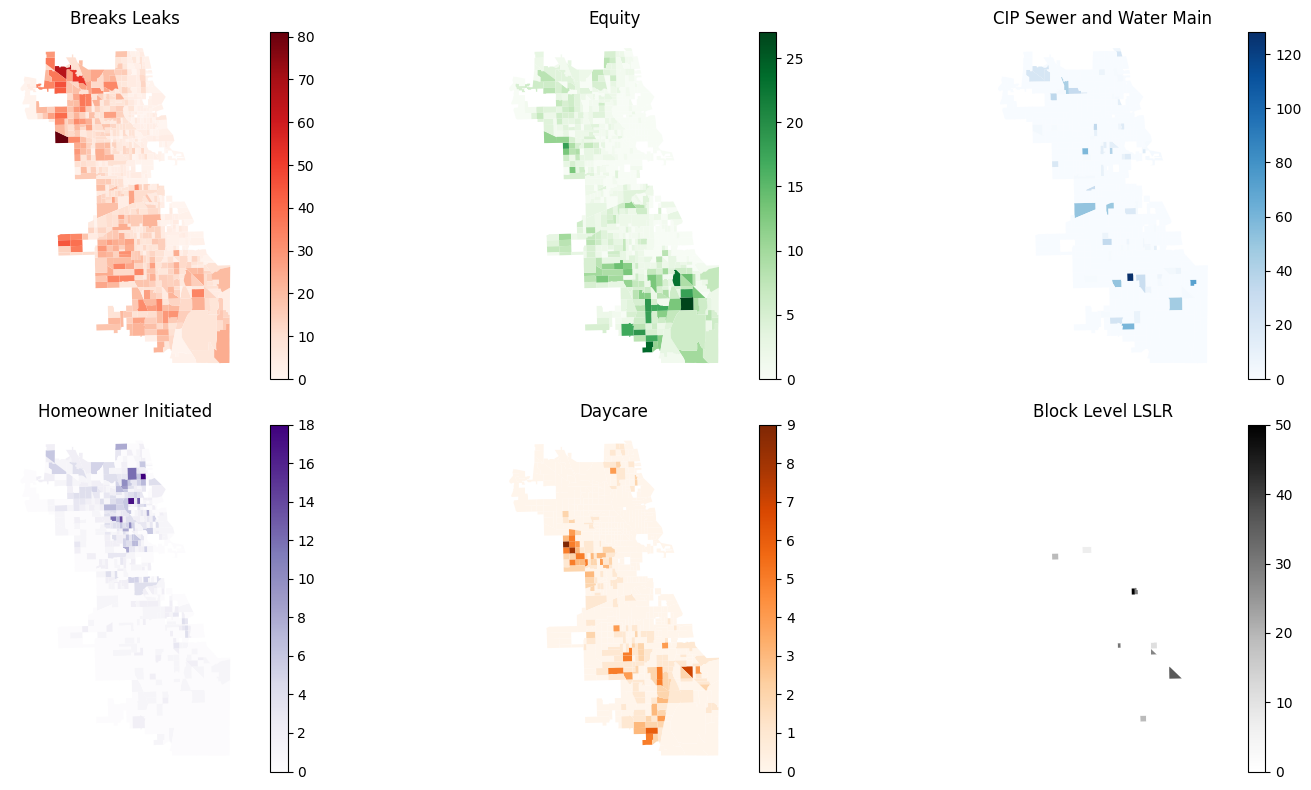

In [178]:
# Create a figure with 6 subplots (2 rows, 3 columns)
fig, ax = plt.subplots(2, 3, figsize=(16, 8))

# Flatten axes for easy indexing
ax = ax.flatten()

# Plot on the first subplot
tract_map.plot(ax=ax[0], column='Breaks Leaks', cmap='Reds', legend=True)
ax[0].set_title('Breaks Leaks')

# Plot on the second subplot
tract_map.plot(ax=ax[1], column='Equity', cmap='Greens', legend=True)
ax[1].set_title('Equity')

# Plot on the third subplot
tract_map.plot(ax=ax[2], column='CIP Sewer and Water Main', cmap='Blues', legend=True)
ax[2].set_title('CIP Sewer and Water Main')

# Plot on the fourth subplot
tract_map.plot(ax=ax[3], column='Homeowner Initiated', cmap='Purples', legend=True)
ax[3].set_title('Homeowner Initiated')

tract_map.plot(ax=ax[4], column='Daycare', cmap='Oranges', legend=True)
ax[4].set_title('Daycare')

tract_map.plot(ax=ax[5], column='Block Level LSLR', cmap='Greys', legend=True)
ax[5].set_title('Block Level LSLR')

ax[0].axis('off')
ax[1].axis('off')
ax[2].axis('off')
ax[3].axis('off')
ax[4].axis('off')
ax[5].axis('off')

# Adjust layout
plt.tight_layout()

# Show the plot
plt.show()

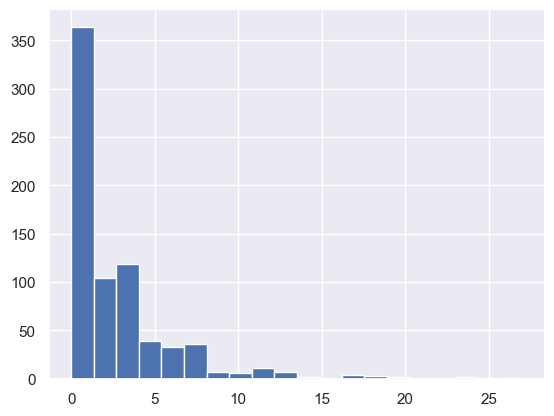

In [242]:
n_bins = 20

tract_analysis['Equity'].hist(bins=n_bins)

plt.show()

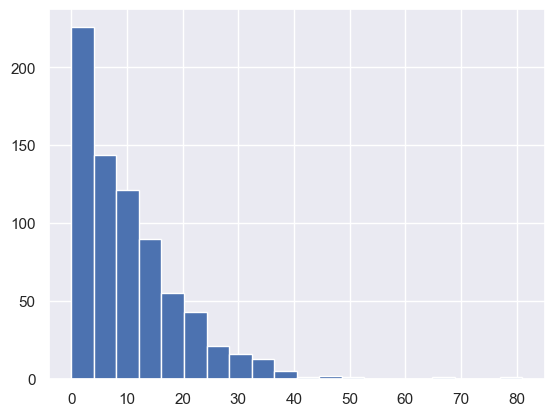

In [243]:
n_bins = 20

tract_analysis['Breaks Leaks'].hist(bins=n_bins)

plt.show()

In [ ]:
n_bins = 20

tract_analysis['Breaks Leaks'].hist(bins=n_bins)

plt.show()

## Analysis of most common replacement by tract or majority replacement by tract

In [245]:
dft = pd.read_csv('../processed/replacement_count_by_tract.csv')

In [246]:
dft.head()

,GEOID,Block Level LSLR,Breaks Leaks,CIP Sewer and Water Main,Daycare,Equity,Homeowner Initiated,Total
0,17031010100,0,3,5,0,1,0,9
1,17031010201,0,2,0,1,2,0,5
2,17031010202,0,2,0,0,0,0,2
3,17031010300,0,5,22,0,0,2,29
4,17031010400,0,2,0,0,0,0,2


In [247]:
len(dft)

740

In [249]:
cols = ["Block Level LSLR","Breaks Leaks","CIP Sewer and Water Main","Daycare","Equity","Homeowner Initiated"]
dft["max"] = dft[cols].idxmax(axis=1)

In [251]:
dft.tail()

,GEOID,Block Level LSLR,Breaks Leaks,CIP Sewer and Water Main,Daycare,Equity,Homeowner Initiated,Total,max
735,17031843700,0,3,0,0,0,6,9,Homeowner Initiated
736,17031843800,0,14,0,0,1,0,15,Breaks Leaks
737,17031843900,0,3,0,1,0,0,4,Breaks Leaks
738,17031844600,0,1,0,0,0,2,3,Homeowner Initiated
739,17031844700,0,19,29,0,4,1,53,CIP Sewer and Water Main


In [253]:
def get_maxes(row):
    max_val = row[cols].max()
    return [col for col in cols if row[col] == max_val]

dft["maxes"] = dft.apply(get_maxes, axis=1)

In [254]:
dft.head()

,GEOID,Block Level LSLR,Breaks Leaks,CIP Sewer and Water Main,Daycare,Equity,Homeowner Initiated,Total,max,maxes
0,17031010100,0,3,5,0,1,0,9,CIP Sewer and Water Main,[CIP Sewer and Water Main]
1,17031010201,0,2,0,1,2,0,5,Breaks Leaks,"[Breaks Leaks, Equity]"
2,17031010202,0,2,0,0,0,0,2,Breaks Leaks,[Breaks Leaks]
3,17031010300,0,5,22,0,0,2,29,CIP Sewer and Water Main,[CIP Sewer and Water Main]
4,17031010400,0,2,0,0,0,0,2,Breaks Leaks,[Breaks Leaks]


In [255]:
dft.to_csv('../processed/max_program_by_tract.csv', index=False)

In [259]:
# merge with geojson
dft_map = pd.merge(tracts, dft, left_on='GEOID', right_on='GEOID', how='left')
dft_map['maxes_str'] = dft_map['maxes'].astype(str)

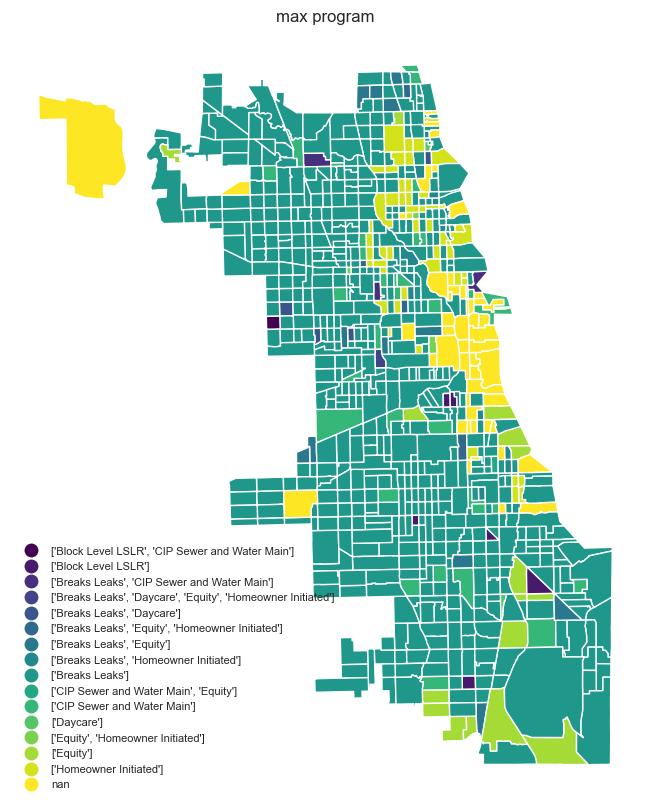

In [273]:
fig, ax = plt.subplots(figsize=(16, 10))

dft_map.plot(
    ax=ax,
    column='maxes_str',
    cmap='viridis',
    legend=True,
    categorical=True,   # force discrete legend
    legend_kwds={
        "loc": "lower left",   # position
        "fontsize": 8,         # shrink text
        "frameon": False       # remove legend box
    }
)

ax.set_title('max program')
ax.axis('off')
plt.show()